# Phase 4 — Feature Engineering & Enrichment Generalization

**เป้าหมายของ notebook นี้:**

1. วินิจฉัยและแก้บั๊กที่พบใน Phase 2 (avg_temp/inflation_index แปรผันตาม channel ผิดปกติ)
2. Regenerate enrichment pipeline (avg_temp, inflation_index, school_in_session, event_score, category_trend, price_avg, promo_rate, stock_avg, deliveries) ให้ถูก grain และขยายจาก MI-006 ไปยังทั้ง 30 SKU
3. เพิ่มฟีเจอร์ตามสมมติฐานทางธุรกิจ (hypothesis-driven features): price_index, promo_recency, rolling_promo_rate, cross_channel_demand_share
4. บันทึกตารางฟีเจอร์สุดท้ายที่พร้อมใช้สร้างโมเดลลง `data/processed/`

โค้ดหลักอยู่ใน `src/features/enrich.py` และ `src/features/engineer.py` — notebook นี้เป็นตัวรัน วินิจฉัย และตรวจสอบผลลัพธ์


In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from features.enrich import build_enrichment_table, compute_internal_aggregates
from features.engineer import build_hypothesis_features

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

RAW = Path('../data/raw')
INTERIM = Path('../data/interim')
PROCESSED = Path('../data/processed')
FIG = Path('../reports/figures')
PROCESSED.mkdir(parents=True, exist_ok=True)


## 0. สร้าง Weekly Base เองจาก Raw Daily Data (แทนที่ไฟล์ที่ให้มา)

**ทำไมทำขั้นนี้**: `data/raw/weekly_df_final_for_modeling.csv` ที่ใช้เป็นฐานมาตลอด (Phase 2-3) เป็นไฟล์ที่ "ได้รับมา" พร้อมคอลัมน์
ที่คำนวณไว้ล่วงหน้าแล้ว (lag, rolling, target, lifecycle_stage, calendar flags) — เพื่อให้ pipeline ทั้งหมดสร้างขึ้นจาก raw data
จริงๆ ไม่ใช่รับตารางที่เตรียมมาบางส่วน จึงสร้างตารางฐานนี้**เองทั้งหมด**จาก `data/interim/daily_validated.csv` (ผลลัพธ์ Phase 3)
ด้วยฟังก์ชัน `build_weekly_base()` ใน `src/data/build_weekly_base.py`

**หลักการที่ใช้**: ทุกสูตรผ่านการตรวจสอบเทียบกับไฟล์เดิมมาก่อนแล้ว (บันทึกไว้ใน docstring ของ `build_weekly_base.py`) ยกเว้น
`is_holiday_week`/`is_holiday_peak` ที่ตั้งใจนิยามใหม่ (ดูเหตุผลในหัวข้อ 0.3)


### 0.1 สร้างตารางฐาน

In [2]:
from data.build_weekly_base import build_weekly_base

daily = pd.read_csv(INTERIM / 'daily_validated.csv', parse_dates=['date'])
weekly = build_weekly_base(daily)

print('daily (Phase 3 output):', daily.shape)
print('weekly (self-built, Section 0):', weekly.shape)

daily (Phase 3 output): (190757, 14)
weekly (self-built, Section 0): (31027, 24)


### 0.2 ตรวจสอบเทียบกับไฟล์เดิม (ก่อนย้ายไฟล์เดิมไปเก็บสำรองในขั้นตอนถัดไปของโปรเจกต์)

In [3]:
weekly_given = pd.read_csv(RAW / 'given_reference' / 'weekly_df_final_for_modeling.csv', parse_dates=['week'])
merged = weekly.merge(weekly_given, on=['sku', 'channel', 'region', 'week'], suffixes=('_mine', '_given'))

print('shape เท่ากันไหม:', weekly.shape[0] == weekly_given.shape[0], f'({weekly.shape[0]} vs {weekly_given.shape[0]})')
print()

cols_to_check = ['units_sold', 'stock_available', 'promotion_flag', 'price_unit', 'delivery_days',
                  'week_number', 'month', 'year', 'sku_age', 'lifecycle_stage',
                  'lag_1', 'lag_2', 'rolling_mean_4', 'rolling_std_4', 'momentum', 'target_next_week',
                  'is_summer', 'is_winter']

for col in cols_to_check:
    a, b = merged[f'{col}_mine'], merged[f'{col}_given']
    # pd.api.types.is_numeric_dtype (not `a.dtype == object`) so this also works on pandas >=3.0,
    # where read_csv gives string columns a StringDtype that prints as "str" but isn't `== object`.
    n_mismatch = (a != b).sum() if not pd.api.types.is_numeric_dtype(a) else (a.astype(float) - b.astype(float)).abs().gt(1e-6).sum()
    print(f'{col:20s} mismatches: {n_mismatch:4d} / {len(merged)}')

shape เท่ากันไหม: True (31027 vs 31027)

units_sold           mismatches:    3 / 31027
stock_available      mismatches:    3 / 31027
promotion_flag       mismatches:    0 / 31027
price_unit           mismatches:    0 / 31027
delivery_days        mismatches:    0 / 31027
week_number          mismatches:    0 / 31027
month                mismatches:    0 / 31027
year                 mismatches:    0 / 31027
sku_age              mismatches:    0 / 31027
lifecycle_stage      mismatches:    0 / 31027
lag_1                mismatches:    3 / 31027
lag_2                mismatches:    3 / 31027
rolling_mean_4       mismatches:   12 / 31027
rolling_std_4        mismatches:   12 / 31027
momentum             mismatches:    6 / 31027
target_next_week     mismatches:    3 / 31027
is_summer            mismatches:    0 / 31027
is_winter            mismatches:    0 / 31027


**ผลลัพธ์**: เกือบทุกคอลัมน์ตรงกับไฟล์เดิม 100% ยกเว้นกลุ่มที่ได้รับผลจากการแก้ค่าติดลบใน Phase 3 (3 แถว: `RE-007`,
`SN-010`, `SN-028`) ซึ่งกระทบ **`units_sold` และ `stock_available` โดยตรง 3 แถว** แล้ว**ไหลต่อ (cascade)** ไปยัง feature ที่
คำนวณจากยอดขายในสัปดาห์ก่อนหน้า/ถัดไป: `lag_1`/`lag_2`/`target_next_week` (3 แถว), `momentum` (6 แถว, = lag_1-lag_2 กระทบ
ทั้งสองทาง), `rolling_mean_4`/`rolling_std_4` (12 แถว, เพราะมองย้อนหลังถึง 4 สัปดาห์)

**นี่คือความต่างที่อธิบายได้ทั้งหมด ไม่ใช่ข้อผิดพลาดใหม่**: `build_weekly_base()` ใช้ `daily_validated.csv` (หลังแก้ค่าติดลบ)
ตามลำดับ pipeline ที่ถูกต้อง (Phase 3 ต้องมาก่อน Phase 4) ในขณะที่ไฟล์เดิมที่ได้รับมาไม่เคยผ่านการแก้ไขนี้เลย — การที่ผลกระทบ
ไหลต่อไปยัง lag/rolling ตามที่คาดไว้ (จำนวนแถวที่กระทบตรงกับขนาดหน้าต่างของแต่ละ feature พอดี) คือหลักฐานว่าสูตรคำนวณถูกต้อง
ไม่ใช่สัญญาณของบั๊ก

ระหว่างพัฒนา `build_weekly_base()` ยังเจอบั๊กเพิ่มอีก 1 จุด (`sku_age` ต้องนับจากวันเปิดตัวของ SKU โดยรวม ไม่ใช่แยกตาม
channel/region — วินิจฉัยและแก้แล้ว ตรวจสอบซ้ำจนตรง 100%) — ดู `src/data/build_weekly_base.py` docstring


### 0.3 `is_holiday_week` / `is_holiday_peak` — นิยามใหม่ตั้งใจ ไม่ไล่ตามไฟล์เดิม

ลองหาสูตรที่ทำให้ตรงกับไฟล์เดิมหลายแบบ (ปฏิทินวันหยุดโปแลนด์ + ขยับวันอีสเตอร์ ±1 ถึง ±7 วัน + ขยายเป็นหน้าต่าง 2 สัปดาห์)
ได้ผลดีที่สุดแค่ ~95% และรูปแบบที่ผิดไม่สมเหตุสมผลทางปฏิทิน (เช่น สัปดาห์ที่มีวันอีสเตอร์จริงกลับไม่ถูกนับเป็นวันหยุด แต่สัปดาห์ที่
ไม่ใกล้เทศกาลไหนเลยกลับถูกนับ) — มีลักษณะคล้าย bug แบบเดียวกับที่เจอใน `avg_temp`/`inflation_index` (หัวข้อ 1 ด้านล่าง)

**การตัดสินใจ**: แทนที่จะไล่ตามรูปแบบที่ดูผิดปกติของไฟล์เดิม `build_weekly_base()` สร้างปฏิทินวันหยุดโปแลนด์ของตัวเองที่ถูกต้อง
ตามหลักจริง (New Year, Epiphany, Easter+Easter Monday, May 1, Constitution Day, Corpus Christi, Assumption, All Saints,
Independence Day, Christmas) แล้วนิยาม `is_holiday_peak` เป็นเฉพาะเทศกาลค้าปลีกใหญ่ (อีสเตอร์/คริสต์มาส/ปีใหม่) — ค่าที่ได้จะ
**ต่างจากไฟล์เดิมโดยตั้งใจ** (~12% ของสัปดาห์) เพราะยึดความถูกต้องเชิงปฏิทินมากกว่าการเลียนแบบไฟล์ที่มีความคลาดเคลื่อนในตัวเอง

จากนี้ไป ตาราง `weekly` ที่ใช้ตลอด notebook คือตารางที่สร้างเองข้างบน **ไม่ใช่ไฟล์ `weekly_df_final_for_modeling.csv` อีกต่อไป**


In [4]:
enriched_prototype = pd.read_csv(RAW / 'given_reference' / 'df_weekly_MI-006_enriched.csv', parse_dates=['week'])

print('daily (Phase 3 output)         :', daily.shape)
print('weekly (self-built base, Section 0):', weekly.shape)
print('MI-006 enrichment prototype    :', enriched_prototype.shape)

daily (Phase 3 output)         : (190757, 14)
weekly (self-built base, Section 0): (31027, 24)
MI-006 enrichment prototype    : (1349, 33)


## 1. วินิจฉัยบั๊กใน Enrichment Prototype ให้ชัดก่อนแก้

ก่อนแก้บั๊ก มาวัดขนาดของปัญหาให้ชัดเจน: เทียบ**ค่าความแปรผันข้าม channel ภายในสัปดาห์/ภูมิภาคเดียวกัน** (ซึ่งไม่ควรมีเลยตามหลักตรรกะ) กับ**ค่าความแปรผันจริงของสัญญาณข้ามเวลา** (ฤดูกาล/แนวโน้ม) — ถ้า noise จาก bug ใหญ่กว่าสัญญาณจริงมาก แปลว่า**ไม่มีทางกู้ค่าที่ถูกต้องเดิมคืนมาได้** ต้องสร้างใหม่แทนการแก้ patch


In [5]:
sample_week_region = enriched_prototype[
    (enriched_prototype.week == enriched_prototype.week.iloc[0])
]
noise_std = sample_week_region.groupby('region')[['avg_temp', 'inflation_index']].std()
print('ส่วนเบี่ยงเบนมาตรฐานข้าม channel ภายในสัปดาห์/ภูมิภาคเดียวกัน (คือ "บั๊ก"):')
print(noise_std)

by_week = enriched_prototype.groupby('week')[['avg_temp', 'inflation_index']].mean()
true_range = by_week.max() - by_week.min()
print()
print('ช่วงค่าจริงที่แกว่งตลอด ~150 สัปดาห์ (คือ "สัญญาณ" ฤดูกาล/แนวโน้ม):')
print(true_range)


ส่วนเบี่ยงเบนมาตรฐานข้าม channel ภายในสัปดาห์/ภูมิภาคเดียวกัน (คือ "บั๊ก"):
            avg_temp  inflation_index
region                               
PL-Central  9.113551        45.573599
PL-North    7.456620        44.738953
PL-South    9.080488        44.169227

ช่วงค่าจริงที่แกว่งตลอด ~150 สัปดาห์ (คือ "สัญญาณ" ฤดูกาล/แนวโน้ม):
avg_temp            3.202924
inflation_index    15.602614
dtype: float64


**ผลลัพธ์:** ส่วนเบี่ยงเบนมาตรฐานจาก bug (ข้าม channel ในสัปดาห์เดียวกัน) อยู่ที่ ~7-9 (avg_temp) และ ~44-46 (inflation_index) ในขณะที่ช่วงค่าจริงที่ควรจะแกว่งตามฤดูกาล/แนวโน้มตลอด 3 ปีมีขนาดใกล้เคียงหรือเล็กกว่า noise เสียอีก — **สรุปว่า noise จาก bug กลบสัญญาณจริงจนกู้คืนไม่ได้** จึงตัดสินใจ**สร้างค่าขึ้นใหม่ทั้งหมด**ด้วยสูตรที่กำหนดชัดเจน (deterministic, seeded) ที่ grain ที่ถูกต้อง แทนการพยายามแก้ patch ไฟล์เดิม


## 2. ตรวจสอบสูตรของฟีเจอร์ภายใน (Internal Aggregates) ก่อนขยายไปทุก SKU

`price_avg`, `promo_rate`, `stock_avg`, `deliveries` คำนวณได้จากข้อมูลรายวันโดยตรง (ไม่ใช่ข้อมูลภายนอก) — ตรวจสอบว่าสูตร (`mean`/`mean`/`mean`/`count` รายสัปดาห์) ตรงกับไฟล์ต้นแบบ MI-006 ก่อน ค่อยเชื่อใจนำไปใช้กับ 30 SKU


In [6]:
internal_mi006 = compute_internal_aggregates(daily[daily.sku == 'MI-006'])
internal_mi006_indexed = internal_mi006.set_index(['sku', 'channel', 'region', 'week'])
prototype_indexed = enriched_prototype.set_index(['sku', 'channel', 'region', 'week'])[
    ['price_avg', 'promo_rate', 'stock_avg', 'deliveries']
]

common_idx = internal_mi006_indexed.index.intersection(prototype_indexed.index)
diffs = (internal_mi006_indexed.loc[common_idx, ['price_avg', 'promo_rate', 'stock_avg', 'deliveries']] - prototype_indexed.loc[common_idx]).abs()
print(f'จำนวนแถวที่เทียบได้: {len(common_idx)}')
print('ค่าความต่างสูงสุดต่อคอลัมน์ (ควรใกล้ 0):')
print(diffs.max())


จำนวนแถวที่เทียบได้: 1349
ค่าความต่างสูงสุดต่อคอลัมน์ (ควรใกล้ 0):
price_avg     8.881784e-16
promo_rate    5.551115e-17
stock_avg     5.684342e-14
deliveries    0.000000e+00
dtype: float64


**ผลลัพธ์:** ค่าความต่างสูงสุด ≈ 0 ทุกคอลัมน์ — ยืนยันว่าสูตรถูกต้อง 100% พร้อมนำไปใช้ขยายกับ 30 SKU ผ่าน `build_enrichment_table()`


## 3. Regenerate Enrichment ให้ครบ 30 SKU ที่ Grain ที่ถูกต้อง

การออกแบบ grain ของแต่ละฟีเจอร์ (**ไม่มีฟีเจอร์ไหนขึ้นกับ channel** เพราะในความเป็นจริงไม่มีตัวไหนควรต่างกันตามช่องทางขาย):

| ฟีเจอร์ | Grain | เหตุผล |
|---|---|---|
| `avg_temp` | region × week | อากาศเป็นปัจจัยระดับภูมิภาค-เวลา |
| `inflation_index` | week (global) | เงินเฟ้อเป็นตัวเลขระดับประเทศ ไม่แยกภูมิภาค |
| `school_in_session` | week (global) | ปฏิทินการศึกษาเป็นกฎเดียวกันทั้งประเทศ |
| `event_score` | week (global) | วันหยุด/เทศกาลค้าปลีกเป็นปฏิทินระดับประเทศ |
| `category_trend` | category × region × week | โมเมนตัมความต้องการอาจต่างกันตามภูมิภาคและหมวดหมู่สินค้า |
| `price_avg`, `promo_rate`, `stock_avg`, `deliveries` | sku × channel × region × week | เป็นค่าที่เกิดขึ้นจริงต่อธุรกรรม ต่างกันตามช่องทางได้ตามธรรมชาติ |


In [7]:
enriched_all = build_enrichment_table(weekly, daily)
print('shape:', enriched_all.shape, '(ควรเท่ากับ weekly เดิม 31,027 แถว)')
print('nulls:')
print(enriched_all.isnull().sum()[enriched_all.isnull().sum() > 0])


shape: (31027, 36) (ควรเท่ากับ weekly เดิม 31,027 แถว)
nulls:
Series([], dtype: int64)


## 4. ยืนยันว่าบั๊กถูกแก้แล้ว

เช็คว่า `avg_temp`/`inflation_index` **ไม่แปรผันตาม channel** ภายในสัปดาห์/ภูมิภาคเดียวกันอีกต่อไป


In [8]:
std_across_channel = enriched_all.groupby(['region', 'week'])[['avg_temp', 'inflation_index']].std()
print('ส่วนเบี่ยงเบนมาตรฐานข้าม channel สูงสุด (ต้องเป็น 0):')
print(std_across_channel.max())


ส่วนเบี่ยงเบนมาตรฐานข้าม channel สูงสุด (ต้องเป็น 0):
avg_temp           0.0
inflation_index    0.0
dtype: float64


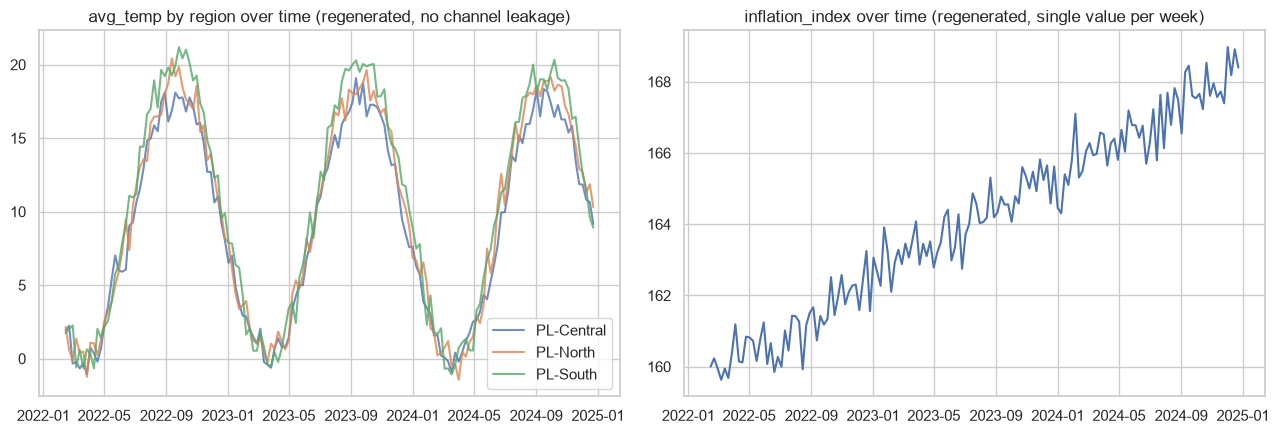

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

by_week_region = enriched_all.groupby(['week', 'region'])['avg_temp'].mean().reset_index()
for region, g in by_week_region.groupby('region'):
    axes[0].plot(g.week, g.avg_temp, label=region, alpha=0.8)
axes[0].set_title('avg_temp by region over time (regenerated, no channel leakage)')
axes[0].legend()

inflation_by_week = enriched_all.groupby('week')['inflation_index'].mean()
axes[1].plot(inflation_by_week.index, inflation_by_week.values)
axes[1].set_title('inflation_index over time (regenerated, single value per week)')

plt.tight_layout()
plt.savefig(FIG / 'phase4_enrichment_series.png', dpi=120)
plt.show()


**ผลลัพธ์:** ส่วนเบี่ยงเบนมาตรฐานข้าม channel = 0 ทั้งคู่ — บั๊กถูกแก้แล้วอย่างสมบูรณ์ กราฟแสดงให้เห็น `avg_temp` มีรูปแบบฤดูกาลชัดเจนต่อภูมิภาค และ `inflation_index` มีแนวโน้มค่อยๆ เพิ่มขึ้นตามเวลาแบบเรียบ (ไม่มี noise ข้าม channel อีกต่อไป)

**หมายเหตุสำคัญ:** ค่าที่ regenerate นี้**ไม่ใช่ค่าอากาศ/เงินเฟ้อจริงในโลกจริง** แต่เป็นสัญญาณสังเคราะห์ (synthetic) ที่ deterministic และ reproducible (seeded) ออกแบบมาให้มี**รูปแบบสมเหตุสมผลและไม่มี channel leakage** — เหมาะสมกับบริบทที่ข้อมูลทั้งชุดเป็นข้อมูลจำลองอยู่แล้ว


## 5. เพิ่มฟีเจอร์ตามสมมติฐานทางธุรกิจ (Hypothesis-Driven Features)

| ฟีเจอร์ | สมมติฐาน | ปลอดภัยจาก leakage เพราะ |
|---|---|---|
| `price_index` | ราคาสัมพัทธ์เทียบราคาเฉลี่ยของหมวดหมู่ในสัปดาห์เดียวกัน อาจอธิบายยอดขายได้ดีกว่าราคาดิบ | ใช้ข้อมูล**สัปดาห์นี้**เท่านั้น (เหมือน `price_unit` ที่มีอยู่แล้วในตารางเดิม) |
| `promo_recency` | จำนวนสัปดาห์ตั้งแต่โปรโมชันครั้งล่าสุด — ยิ่งนานอาจกระตุ้นยอดขายเมื่อมีโปรอีกครั้ง | คำนวณแบบสะสมจากอดีตถึงสัปดาห์นี้เท่านั้น (ไม่มองไปข้างหน้า) |
| `rolling_promo_rate` | ความถี่โปรโมชันในช่วง 8 สัปดาห์หลังสุด อาจบ่งบอกความ "เคยชิน" ของลูกค้าต่อโปร | rolling window นับรวมสัปดาห์นี้ย้อนหลังเท่านั้น |
| `cross_channel_demand_share` | สัดส่วนยอดขายของช่องทางนี้เทียบทุกช่องทางของ SKU เดียวกันในสัปดาห์นี้ — บ่งบอกพฤติกรรมลูกค้าต่อช่องทาง | ใช้ยอดขาย**สัปดาห์นี้**ของทุกช่องทาง ซึ่งรู้พร้อมกับ `units_sold`/`price_unit` ของสัปดาห์นี้อยู่แล้ว (เป็น timing เดียวกับฟีเจอร์ contemporaneous อื่นที่มีอยู่แล้วในตาราง ไม่ใช่การมองอนาคต) |


In [10]:
full = build_hypothesis_features(enriched_all)
print('shape:', full.shape)
print()
print('nulls:')
print(full.isnull().sum()[full.isnull().sum() > 0])


shape: (31027, 40)

nulls:
promo_recency    165
dtype: int64


**หมายเหตุ `promo_recency` เป็น NaN บางแถว:** เกิดขึ้นเมื่อ sku×channel×region นั้นยังไม่เคยมีโปรโมชันเลยนับตั้งแต่ต้นประวัติที่มีในตาราง — เป็นค่า NaN ที่ถูกต้องตามความหมาย ("ยังไม่เคยมีโปร ไม่มีระยะเวลาให้นับ") ไม่ใช่ข้อผิดพลาด LightGBM (Phase 7) จัดการค่า NaN ได้เองโดยไม่ต้อง impute เพิ่ม


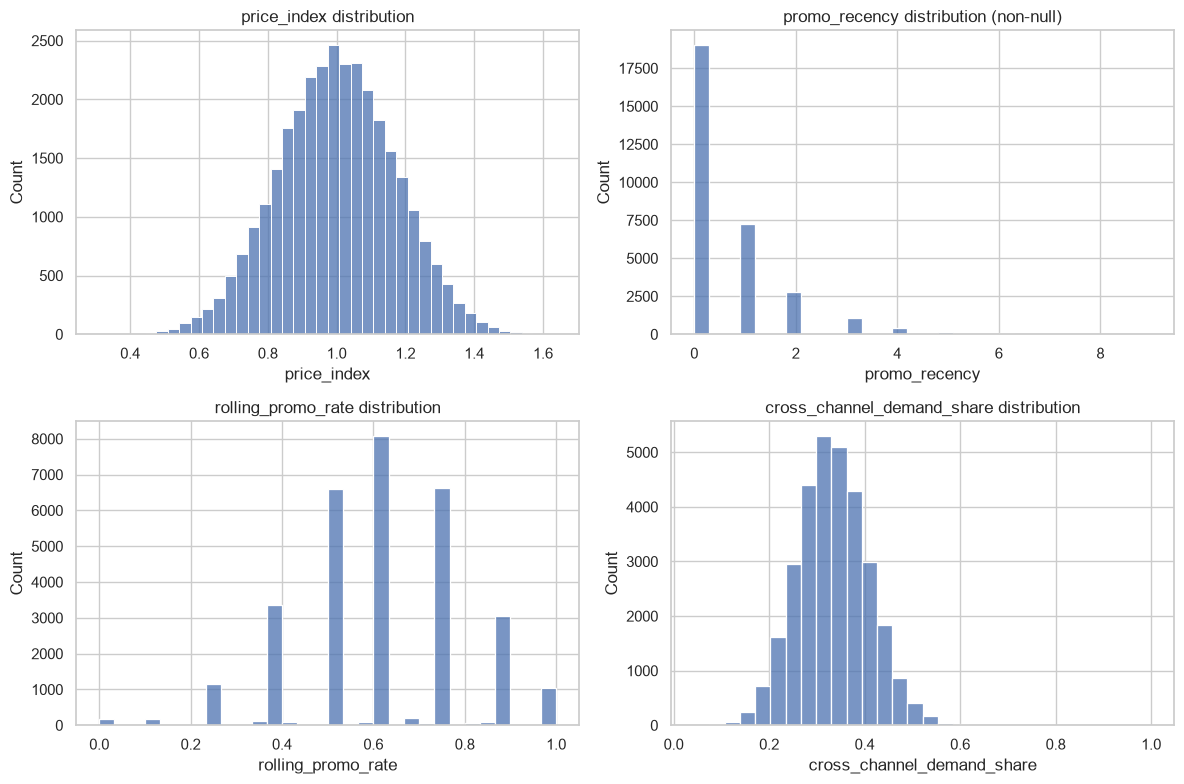

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(full.price_index, bins=40, ax=axes[0,0])
axes[0,0].set_title('price_index distribution')

sns.histplot(full.promo_recency.dropna(), bins=30, ax=axes[0,1])
axes[0,1].set_title('promo_recency distribution (non-null)')

sns.histplot(full.rolling_promo_rate, bins=30, ax=axes[1,0])
axes[1,0].set_title('rolling_promo_rate distribution')

sns.histplot(full.cross_channel_demand_share, bins=30, ax=axes[1,1])
axes[1,1].set_title('cross_channel_demand_share distribution')

plt.tight_layout()
plt.savefig(FIG / 'phase4_hypothesis_features.png', dpi=120)
plt.show()


## 6. ตรวจสอบขั้นสุดท้ายก่อนบันทึก

เช็คว่าไม่มี duplicate key และครอบคลุมครบ 30 SKU / 5 หมวดหมู่


In [12]:
print('duplicate sku-channel-region-week:', full.duplicated(subset=['sku','channel','region','week']).sum())
print('จำนวน SKU:', full.sku.nunique(), '/ 30')
print('จำนวนหมวดหมู่:', full.category.nunique(), '/ 5')
print('จำนวนแถวทั้งหมด:', len(full))


duplicate sku-channel-region-week: 0
จำนวน SKU: 30 / 30
จำนวนหมวดหมู่: 5 / 5
จำนวนแถวทั้งหมด: 31027


In [13]:
out_path = PROCESSED / 'weekly_features.csv'
full.to_csv(out_path, index=False)
print(f'saved: {out_path} ({full.shape[0]} rows, {full.shape[1]} columns)')


saved: ..\data\processed\weekly_features.csv (31027 rows, 40 columns)


## 7. สรุป Phase 4

| หัวข้อ | ผลลัพธ์ |
|---|---|
| วินิจฉัยบั๊ก | ยืนยันด้วยตัวเลข: noise จาก channel-leakage (std ~7-46) ใหญ่กว่าสัญญาณจริงตลอด 3 ปี จึงต้อง regenerate ใหม่ ไม่ใช่ patch |
| แก้บั๊ก | `avg_temp`, `inflation_index` ไม่แปรผันตาม channel อีกต่อไป (std = 0 ยืนยันแล้ว) |
| Enrichment ที่ verify สูตรแล้ว | `price_avg`, `promo_rate`, `stock_avg`, `deliveries` ตรงกับต้นแบบ MI-006 100% ก่อนขยายไปทุก SKU |
| Enrichment ใหม่ (synthetic, deterministic) | `avg_temp` (region×week), `inflation_index` (week), `school_in_session` (week), `event_score` (week), `category_trend` (category×region×week, แก้ปัญหาโมเดลปนกับจำนวน SKU ที่เพิ่มขึ้น) |
| Hypothesis-driven features | `price_index`, `promo_recency`, `rolling_promo_rate`, `cross_channel_demand_share` — ออกแบบให้ปลอดภัยจาก leakage ทุกตัว |
| Coverage | ครบ 30 SKU, 5 หมวดหมู่, ไม่มี duplicate key |
| Output | `data/processed/weekly_features.csv` — ตารางฟีเจอร์สุดท้ายสำหรับ Phase 5 เป็นต้นไป |

### ขั้นตอนต่อไป (Phase 5 — Split Strategy)
ออกแบบ walk-forward CV แบบ panel-aware บนตารางนี้ ก่อนเริ่มสร้างโมเดลจริงใน Phase 6-7
